# Первичная обработка данных

## Подготовка

### Импорты

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

from avito_candidate_gen.data import load_train

### Загрузка данных

In [2]:
data_train = load_train()

In [3]:
data_train.shape

(497673, 19)

Датасет содержит 497 673 строки и 19 колонок.

## Общая структура и качество


### Обзор колонок


Посмотрим кол-во уникальных запросов по `seach_query`, так как далее данные будут разбиты на train/val по этому признаку, чтобы не допустить утечек.

In [4]:
print(f"Кол-во строк: {len(data_train):,}")
print(f"Кол-во уникальных запросов: {data_train["search_query"].nunique():,}")

data_train.head(3)

Кол-во строк: 497,673
Кол-во уникальных запросов: 74,529


,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.0,2303374,39.712818,652430,54.629230,True,False,Вид услуги Место оказания услуг Первомайский п...,e8b685dffe1a408e,Скупаю практически любую современную новую и б...,114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.0,2303374,44.051010,640860,56.273390,False,False,Вид услуги Место оказания услуг Нижний Новгоро...,92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля...,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви...",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.0,86469,30.128784,653240,59.783688,False,False,"Вид услуги Красота, здоровье Место оказания ус...",624846856ce81d69,В ритме современной жизни так сложно найти мо...,114


In [5]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 497673 entries, 0 to 497672
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   search_query               497673 non-null  str    
 1   search_location_id         497673 non-null  int64  
 2   search_is_delivery_search  497673 non-null  int32  
 3   search_infm_params_text    497673 non-null  str    
 4   search_category            497673 non-null  int64  
 5   item_title_raw             497673 non-null  str    
 6   item_rating_reviews_count  478462 non-null  float64
 7   item_rating                469441 non-null  float64
 8   item_price                 497673 non-null  float64
 9   item_microcat_id           497673 non-null  int64  
 10  item_longitude             497669 non-null  float64
 11  item_location_id           497673 non-null  int64  
 12  item_latitude              497669 non-null  float64
 13  item_is_phone_hidden       497673 non-nu

Предварительно видно некоторые особенности: 
- `item_price`, `item_latitude`, `item_longitude` имели тип `object`, логика перевода во float была вынесена в data.py;
- некоторые содержат пропуски

### Технические аномалии

Посмотрим пропуски

In [6]:
data_train[data_train["item_latitude"].isna()][
    ["item_id", "item_location_id", "item_latitude", "item_longitude"]
]

,item_id,item_location_id,item_latitude,item_longitude
29613,54afeb60e0ae0a31,653240,NaN,NaN
181601,54afeb60e0ae0a31,653240,NaN,NaN
238596,84e0948ae2b07c13,637640,NaN,NaN
418344,0f69da8de47590fd,621576,NaN,NaN


Точные координаты не так важны в данном случае, поскольку привязка к локации остается. Пропуски в рейтинге не играют роли в решаемой задаче.

## Статистика объявлений

### Длина текста

In [7]:
title_len = data_train["item_title_raw"].apply(lambda x: len(str(x).split()))

desc_len = data_train["item_description_raw"].apply(lambda x: len(str(x).split()))

print("Длина заголовка (слов):")
print(title_len.describe())

print("\nДлина описания (слов):")
print(desc_len.describe())

Длина заголовка (слов):
count    497673.000000
mean          4.359813
std           2.003450
min           1.000000
25%           3.000000
50%           4.000000
75%           6.000000
max          22.000000
Name: item_title_raw, dtype: float64

Длина описания (слов):
count    497673.000000
mean        175.876035
std         166.442919
min           1.000000
25%          51.000000
50%         127.000000
75%         249.000000
max        1568.000000
Name: item_description_raw, dtype: float64


Заголовки короткие, что близко к длине самих поисковых запросов.
Описания сильно варьируются по длине, при сборке текстового поля для BM25 заголовку стоит давать больший вес, чем описанию. 

### Дубликаты

Дублирующихся заголовков: 287644 (57.8%)
Дублирующихся описаний: 170325 (34.2%)


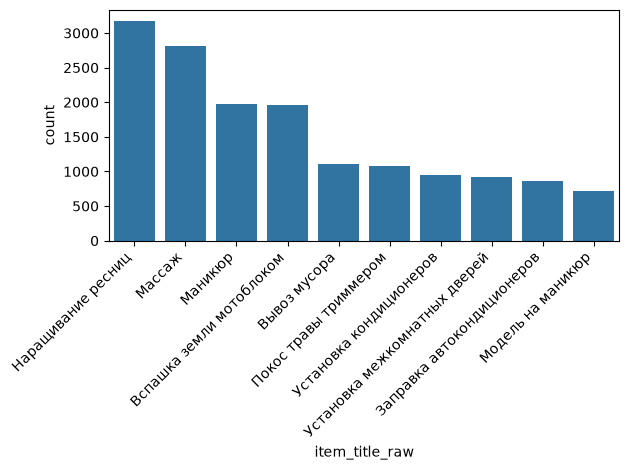

In [8]:
dup_titles = data_train["item_title_raw"].duplicated().sum()
dup_desc = data_train["item_description_raw"].duplicated().sum()

print(f"Дублирующихся заголовков: {dup_titles} ({dup_titles / len(data_train):.1%})")
print(f"Дублирующихся описаний: {dup_desc} ({dup_desc / len(data_train):.1%})")

counts = data_train["item_title_raw"].value_counts().head(10)

sns.countplot(
    data=data_train[data_train["item_title_raw"].isin(counts.index)],
    x="item_title_raw",
    order=counts.index,
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
print("Уникальных item_id:", data_train["item_id"].nunique())
print("Уникальных заголовков:", data_train["item_title_raw"].nunique())

# Среди уникальных объявлений сколько дублей заголовка
unique_items = data_train.drop_duplicates(subset="item_id")
dup_titles_unique = unique_items["item_title_raw"].duplicated().sum()
print(
    f"Дублей заголовка среди уникальных объявлений: {dup_titles_unique} ({dup_titles_unique / len(unique_items):.1%})"
)

Уникальных item_id: 344825
Уникальных заголовков: 210029
Дублей заголовка среди уникальных объявлений: 134796 (39.1%)


Заголовок сам по себе не всегда уникально идентифицирует объявление, поэтому различение объявлений внутри одной категории будет больше опираться на описание/параметры.

### Категории

In [10]:
data_train[["search_category"]].value_counts()

search_category
114                497635
0                      34
81                      2
10                      2
Name: count, dtype: int64

In [11]:
data_train["item_category_id"].value_counts()

item_category_id
114    497658
27          4
40          2
81          2
19          2
28          2
112         2
10          1
Name: count, dtype: int64

Почти 100% объявлений относятся к одной категории, остальные – шум.

In [12]:
print("\nitem_microcat_id:", data_train["item_microcat_id"].nunique(), "значений")
data_train["item_microcat_id"].value_counts(normalize=True).round(3).head(15)


item_microcat_id: 212 значений


item_microcat_id
1289835    0.058
86470      0.038
1289833    0.031
86467      0.025
86469      0.024
2059415    0.021
44730      0.018
1178214    0.018
2301617    0.018
1289834    0.018
2097890    0.016
2301563    0.015
2303374    0.015
1178215    0.014
2169983    0.014
Name: proportion, dtype: float64

item_microcat_id куда информативнее, видно реальное деление по типу услуги. Но у запроса нет отдельного поля-аналога микрокатегории, поэтому прямого matching-сигнала построить нельзя. Этот признак не может быть полезен для буста в кандидато генерации.

### Числовые признаки

In [13]:
data_train["item_price"].describe()

count    4.976730e+05
mean     1.971123e+07
std      3.827554e+09
min     -1.000000e+00
25%      4.000000e+02
50%      1.000000e+03
75%      2.000000e+03
max      1.000000e+12
Name: item_price, dtype: float64

Заметны аномалии в виде отрицательной цены (что может служить каким-то особым идентификатором) и максимума в триллион. Но это поле не важно для кандидатогенерации, поскольку порядок не имеет значения для метрики. Для последующего ранжирования, выбросы необходимо будет обработать.

## Статистика запросов

### Длина запроса

In [14]:
query_len = data_train["search_query"].fillna("").str.split().apply(len)
query_len.describe()

count    497673.000000
mean          2.339287
std           1.067237
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          17.000000
Name: search_query, dtype: float64

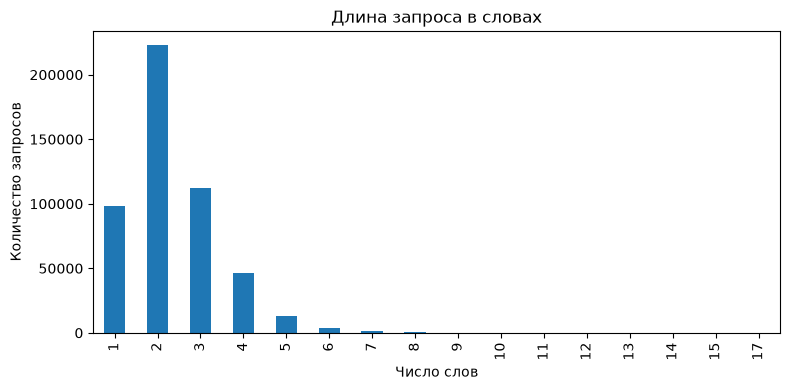

In [15]:
query_len.value_counts().sort_index().plot(kind="bar", figsize=(8, 4))

plt.title(f"Длина запроса в словах")
plt.xlabel("Число слов")
plt.ylabel("Количество запросов")
plt.tight_layout()
plt.show()

Запросы короткие, распределение умеренно скошено (std=1.07 при mean=2.34), в отличие от описаний объявлений, где разброс был экстремальным.


### Частотность запросов

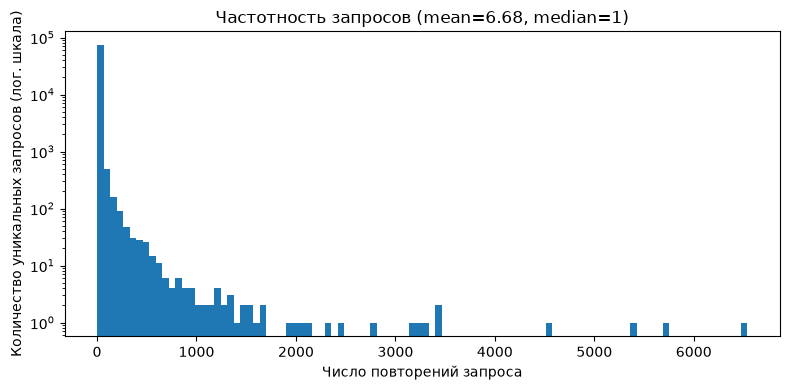

count    74529.000000
mean         6.677575
std         64.865220
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       6540.000000
Name: count, dtype: float64

In [ ]:
query_freq = data_train["search_query"].value_counts()

query_freq.plot(kind="hist", bins=100, log=True, figsize=(8, 4))
plt.title(
    f"Частотность запросов (mean={query_freq.mean():.2f}, median={query_freq.median():.0f})"
)
plt.xlabel("Число повторений запроса")
plt.ylabel("Количество уникальных запросов (лог. шкала)")
plt.tight_layout()
plt.show()

query_freq.describe()

In [17]:
query_freq.head(20)

search_query
маникюр                    6540
массаж                     5702
наращивание ресниц         5395
установка кондиционеров    4573
педикюр                    3436
сантехник                  3405
вывоз мусора               3278
эвакуатор                  3263
электрик                   3158
автоэлектрик               2790
покос травы                2477
вспашка земли              2315
манипулятор                2120
грузоперевозки газель      2034
натяжные потолки           2004
наращивание ногтей         1902
торты на заказ             1682
тонировка                  1644
поклейка обоев             1611
грузчики                   1540
Name: count, dtype: int64

Большинство уникальных текстов запроса встречаются один раз, но есть сильный перекос за счёт немногих сверхчастых запросов. Топ-20 самых частых запросов — популярные бытовые
услуги, совпадают по духу с топ заголовков объявлений.

Для таких частотных запросов recall@50 потенциально ниже: в корпусе тысячи текстово подходящих объявлений, и без дополнительного сужения, например, по локации, топ-50 может не поймать конкретное выбранное пользователем объявление просто из-за конкуренции с большим числом похожих.

### Фильтры поиска

In [18]:
has_infm = data_train["search_infm_params_text"] != ""
print(f"Запросов с фильтрами: {has_infm.mean():.1%}")

data_train.loc[has_infm, "search_infm_params_text"].value_counts().head(15)

Запросов с фильтрами: 67.0%


search_infm_params_text
Вид услуги Автосервис, аренда Тип услуги Автосервис                                                     19654
Вид услуги Ремонт и отделка                                                                             15586
Вид услуги Красота, здоровье                                                                            15355
Вид услуги Праздники, мероприятия                                                                       12474
Тип услуги автосервиса Диагностика и ремонт авто Вид услуги Автосервис, аренда Тип услуги Автосервис    11644
Тип услуги Маникюр, педикюр Вид услуги Красота, здоровье                                                11589
Вид услуги Обучение, курсы                                                                              11080
Вид услуги                                                                                              10566
Вид услуги Грузоперевозки                                                                       

In [19]:
# Пересекается ли search_infm_params_text с item_infm_params_text
# у выбранного объявления, когда фильтр указан?
mask = has_infm

def infm_overlap(search_infm, item_infm):
    s = set(str(search_infm).lower().split())
    i = set(str(item_infm).lower().split())
    return len(s & i) / len(s) if s else 0

overlap_infm = data_train.loc[mask].apply(
    lambda r: infm_overlap(r["search_infm_params_text"], r["item_infm_params_text"]), axis=1
)
overlap_infm.describe()

count    333674.000000
mean          0.970561
std           0.114666
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
dtype: float64

In [20]:
# Посмотрим на пример item_infm_params_text рядом с search_infm_params_text
data_train.loc[mask, ["search_infm_params_text", "item_infm_params_text"]].sample(5, random_state=42)

,search_infm_params_text,item_infm_params_text
38318,Вид услуги,Вид услуги Место оказания услуг Санкт-Петербур...
250861,"Тип услуги Скважины, септики, колодцы Вид услу...","Вид услуги Сад, благоустройство Место оказания..."
325220,Тип услуги Услуги парикмахера Вид услуги Красо...,"Вид услуги Красота, здоровье Место оказания ус..."
180776,Вид услуги Ремонт и отделка,Вид услуги Ремонт и отделка Тип услуги Место о...
143945,Вид услуги Уход за животными,Вид услуги Уход за животными Место оказания ус...


67% запросов содержат фильтры в текстовом виде: «Вид услуги X», «Тип услуги Y Вид услуги X» — двухуровневая иерархия. Проверка пересечения слов с item_infm_params_text выбранного объявления дала почти полное включение текста фильтра в параметры объявления.

Значит search_infm_params_text — надёжный признак для буста score кандидатов, по силе значительно превосходящий search_category, который оказался почти бесполезным, и превосходящий совпадение по локации (83.1%). Однако сигнал доступен только для 67% запросов, где фильтр указан, а для остальных 33% нужно полагаться на текстовый поиск и локацию.

### Локация запроса

In [21]:
print("search_location_id:", data_train["search_location_id"].nunique(), "значений")
data_train["search_location_id"].value_counts(normalize=True).round(3).head(10)

search_location_id: 2782 значений


search_location_id
637640    0.073
653240    0.051
107620    0.025
633540    0.023
650400    0.022
654070    0.016
641780    0.016
625810    0.016
652000    0.016
646600    0.015
Name: proportion, dtype: float64

search_location_id имеет достаточно равномерное распределение, поэтому локация остаётся содержательным признаком для сужения пространства поиска.

## Связь запроса и релевантного объявления

### Лексическое пересечение

In [22]:
def word_overlap(query, text):
    q_words = set(str(query).lower().split())
    t_words = set(str(text).lower().split())
    return len(q_words & t_words) / len(q_words) if q_words else 0


combined_text = data_train["item_title_raw"] + " " + data_train["item_description_raw"]

overlap = data_train.apply(
    lambda x: word_overlap(x["search_query"], combined_text[x.name]), axis=1
)
overlap.describe()

count    497673.000000
mean          0.684599
std           0.371273
min           0.000000
25%           0.500000
50%           1.000000
75%           1.000000
max           1.000000
dtype: float64

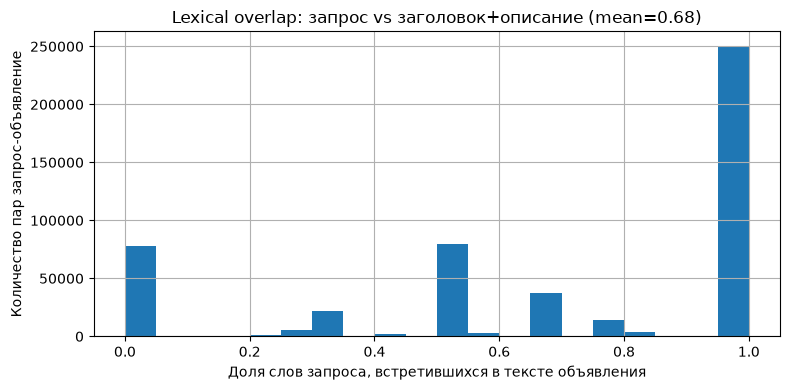

Доля пар с overlap = 0: 15.7%


In [23]:
overlap.hist(bins=20, figsize=(8, 4))
plt.title(f"Lexical overlap: запрос vs заголовок+описание (mean={overlap.mean():.2f})")
plt.xlabel("Доля слов запроса, встретившихся в тексте объявления")
plt.ylabel("Количество пар запрос-объявление")
plt.tight_layout()
plt.show()

# Точная доля случаев с нулевым overlap - важна для обоснования semantic retrieval
zero_overlap = (overlap == 0).mean()
print(f"Доля пар с overlap = 0: {zero_overlap:.1%}")

Распределение пересечения трёхмодальное с пиками на 0.0, ~0.5 и 1.0, и с "провалами" между ними. Это объясняется дискретностью коротких запросов (медиана 2 слова), отсюда такая форма графика.

Главное – 15.7% пар запрос-объявление не имеют ни одного общего слова между запросом и полным текстом объявления. Это говорит о необходимости semantic retrieval, как отдельного источника кандидатов.

## Проверка тестового корпуса

Проверю совпадение параметров с тренировочной выборкой

In [24]:
from avito_candidate_gen.data import load_benchmark_items

df_items = load_benchmark_items()
df_items.shape
df_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 189212 entries, 0 to 189211
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   item_title_raw             189212 non-null  str    
 1   item_rating_reviews_count  177597 non-null  float64
 2   item_rating                171581 non-null  float64
 3   item_price                 189212 non-null  float64
 4   item_microcat_id           189212 non-null  int64  
 5   item_longitude             189211 non-null  float64
 6   item_location_id           189212 non-null  int64  
 7   item_latitude              189211 non-null  float64
 8   item_is_phone_hidden       189212 non-null  bool   
 9   item_is_message_forbidden  189212 non-null  bool   
 10  item_infm_params_text      189212 non-null  str    
 11  item_id                    189212 non-null  str    
 12  item_description_raw       189177 non-null  str    
 13  item_category_id           189212 non-nu

## Итоговые выводы

### Качество данных

- `item_price`, `item_latitude`, `item_longitude` хранились как `Decimal` — приведение к `float` встроено в загрузчики;
- пропуски незначительны и не требуют удаления строк;
- item_id и заголовки объявлений массово повторяются. Заголовок сам по себе не всегда уникально идентифицирует объявление, различение ложится на описание/параметры.


### Сигналы для кандидатогенерации


| Сигнал | Сила | Решение |
|---|---|---|
| `search_infm_params_text` & `item_infm_params_text` | Очень сильный (overlap mean=0.97, покрывает 67% запросов) | Буст score, когда фильтр указан |
| `search_location_id` & `item_location_id` | Сильный (83.1% точных совпадений, 2782 разумно распределённых значения) | Буст score, не жёсткий фильтр |
| Запрос & заголовок+описание | Средний, но с провалом (mean=0.68, но 15.7% пар без единого общего слова) | Основа BM25-baseline + обоснование для semantic retrieval |
| `search_category` & `item_category_id` | Практически бесполезен (4 и 8 значений, ~100% сидит в одной категории) | Не использовать |
| `item_price`, `item_rating` | Не применимо к задаче | Ranking-признаки не нужны для recall@50, нет аналога в search-полях |



### Особенности задачи


- Запросы и заголовки объявлений компактны и однотипны, что облегчает лексический поиск для большинства случаев.
- Топ запросов: маникюр, массаж и т.д., встречаются тысячи раз. Для них recall@50 потенциально структурно ниже, поэтому стоит оценивать recall отдельно по частотным/редким запросам на этапе валидации.
- Описания объявлений сильно различаются по длине, это надо учитывать при сборке текста для BM25 (вес заголовка выше) и для эмбеддингов (ограничение длины входа модели).



### Решения для следующих шагов пайплайна



1. **Baseline (`02_baseline_bm25.ipynb`)**: BM25 по тексту `item_title_raw` (больший вес) + `item_description_raw` + `item_infm_params_text`. Ожидается не выше 84% (100% − 15.7% пар без лексического пересечения), если полагаться только на текст.
2. **Буст по локации и фильтрам (`03_...`)**: добавить бонус к score объявлений с совпадающим `item_location_id` и с пересечением `item_infm_params_text` с `search_infm_params_text` (когда фильтр указан)